# 第39课 · 重写 1965 年改变世界的算法——从零递归实现 FFT（Cooley-Tukey），误差 < 1e-10

**目标**：先把偶奇拆分、递归基线和蝶形合并串成一条线，再亲手写出 Cooley-Tukey 递归 FFT，并把误差压到 $< 10^{-10}$。

> **实现课要点**：递归基线 $N=1$（单点 DFT = 自身）；L38 懂「为什么快」，本课写出递归。位逆序可后置选学。

🔗 **Aurora 连接**：对照 `transforms.py` 里的 `fft()`，你会看到本课写出的递归版和生产代码在数学上完全一致。

← **上一课**　[L38 · FFT 蝶形分治](L38_fft_butterfly.ipynb)

> 上节课学习了 **FFT 蝶形分治**：偶奇拆分、蝶形运算 E[k]+W^k·O[k]，O(N²)→O(N log N)。  
> 本课将探讨 **从零手写 FFT**。

## 本课剧情：为什么"把大问题砍成两半"就能快 200 倍？

有道经典面试题：在一个有 1024 层的高塔里，找到某个楼层只需二分查找——每次砍半，最多 log₂1024=10 步。

FFT 做的正是同样的事情。DFT 需要对每个频点扫描全部 N 个样本——N 个频点 × N 个样本 = **N² 次乘法**。FFT 问："能不能只扫一半样本，然后把两个半结果合并成完整结果？"

**Cooley-Tukey 的答案**（1965）：

$$X[k] = \underbrace{\text{DFT}(x_{\text{even}})[k]}_{E[k]} + e^{-2\pi i k/N} \cdot \underbrace{\text{DFT}(x_{\text{odd}})[k]}_{O[k]}$$

把"偶数下标序列"和"奇数下标序列"各做 N/2 点 DFT，再用一次蝶形合并得到完整 N 点结果。这个分治（divide and conquer）**可以递归**：N/2 → N/4 → ... → 1（基础情形：单点 DFT 就是 x[0]）。

**效率**：log₂N 层 × N/2 蝶形/层 = **(N/2)·log₂N** 次乘法。

| N | DFT 乘法 | FFT 乘法 | 加速比 |
|---|---|---|---|
| 64 | 4096 | 192 | 21× |
| 1024 | 1048576 | 5120 | 205× |
| 4096 | 16777216 | 24576 | 682× |

本节任务：实现 `my_fft(x)` 递归 Cooley-Tukey FFT，并验证与 `np.fft.fft` 误差 < 1e-9。

## 预备：从 DFT 定义推导 Cooley-Tukey 公式

学生们问"这个公式从何而来？"——让我们从最基础的 DFT 定义开始，一步步推导出为什么偶奇拆分就能加速。

**DFT 的定义**（你已经很熟悉）：
$$X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-2\pi i k n / N}$$

现在，把求和分成两部分：偶数下标 $n=2m$ 和奇数下标 $n=2m+1$：
$$X[k] = \sum_{m=0}^{N/2-1} x[2m] \cdot e^{-2\pi i k (2m) / N} + \sum_{m=0}^{N/2-1} x[2m+1] \cdot e^{-2\pi i k (2m+1) / N}$$

对第一项，指数变成 $e^{-2\pi i k m / (N/2)}$，这正好是**长度 N/2 的 DFT**的定义形式。设 $E[k] = \text{DFT}(x[0,2,4,...])$；

对第二项，先提出 $e^{-2\pi i k / N}$（这就是"旋转因子"），剩下的是 $e^{-2\pi i k m / (N/2)}$，这是 $\text{DFT}(x[1,3,5,...])$。设 $O[k] = \text{DFT}(x[1,3,5,...])$；

**所以**：
$$X[k] = E[k] + e^{-2\pi i k/N} \cdot O[k]$$

现在对第二个频点 $X[k + N/2]$，因为周期性 $e^{-2\pi i (k+N/2) n / N} = e^{-2\pi i k n / N} \cdot e^{-2\pi i n/2}$，而 $e^{-2\pi i n/2}$ 对偶数 $n=2m$ 得 $e^{-2\pi i m} = 1$（周期为 1），对奇数 $n=2m+1$ 得 $e^{-\pi i} \cdot e^{-2\pi i m} = -1$。所以：

$$X[k+N/2] = E[k] - e^{-2\pi i k/N} \cdot O[k]$$

**这就是 Cooley-Tukey 公式的完整推导。** 减号不是凭空出现，而是复指数的周期性自动给出的。

## 关键概念：复数乘法就是旋转——为什么 $e^{-2\pi i k/N}$ 是"旋转因子"

你可能看到代码 `twiddle = np.exp(-2j * np.pi * k / N)`，然后 `E + twiddle * O`，感觉就是"用一个复数乘法"。但**为什么这个乘法就能代表"旋转"**？让我们用几何直观来理解。

**欧拉公式回顾**：
$$e^{i\theta} = \cos\theta + i\sin\theta$$

这个式子在复平面上代表什么？一个**单位圆上的点**，角度为 $\theta`（从实轴正方向逆时针）。

- $e^{i \cdot 0} = 1 + 0i = (1, 0)$——指向东方
- $e^{i \pi/2} = 0 + 1i = (0, 1)$——指向北方
- $e^{i \pi} = -1 + 0i = (-1, 0)$——指向西方  
- $e^{i \cdot 3\pi/2} = 0 - 1i = (0, -1)$——指向南方

**复数乘法就是旋转**：当你用 $e^{i\theta}$ 乘以另一个复数 $z = a + bi$ 时，结果就是"把 $z$ 绕原点旋转 $\theta$ 角度"。例如：

$$e^{i\pi/2} \cdot 1 = i$$

在复平面上，1 是指向东的单位向量，乘以 $e^{i\pi/2}$（代表"旋转 90°"）后得到 $i$，指向北。

$$e^{i\pi} \cdot (2+0i) = (-1) \cdot (2+0i) = -2$$

2 乘以 $e^{i\pi}$（旋转 180°）后指向西。

**在 FFT 里**：旋转因子 $e^{-2\pi i k/N}$ 对每个频点 $k=0,1,2,...,N/2-1$ 都会旋转不同的角度（$0° \to -\frac{360°}{N} \to -\frac{720°}{N} \to ...$）。这些旋转是为了"对齐"偶数项和奇数项的相位差——因为原始信号的偶数位和奇数位天然相差一个样本延迟（时间延迟对应相位旋转）。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


手工计算复数乘法：(1+0j) × e^(-iπ/2)
  e^(-iπ/2) = 0.0000-1.0000j  (应该是 -i = 0-1j)
  (1+0j) × 0.0000-1.0000j = 0.0000-1.0000j  (旋转 -90°，从东转向南)

手工计算：x_odd 乘旋转因子后 N=4, k=1 的情形
  O[1] = (2+0j)
  W_4^1 = e^(-2πi/4) = e^(-πi/2) = 0.0000-1.0000j
  O[1] × W_4^1 = (2+0j) × 0.0000-1.0000j = 0.0000-2.0000j  (旋转 -90°)


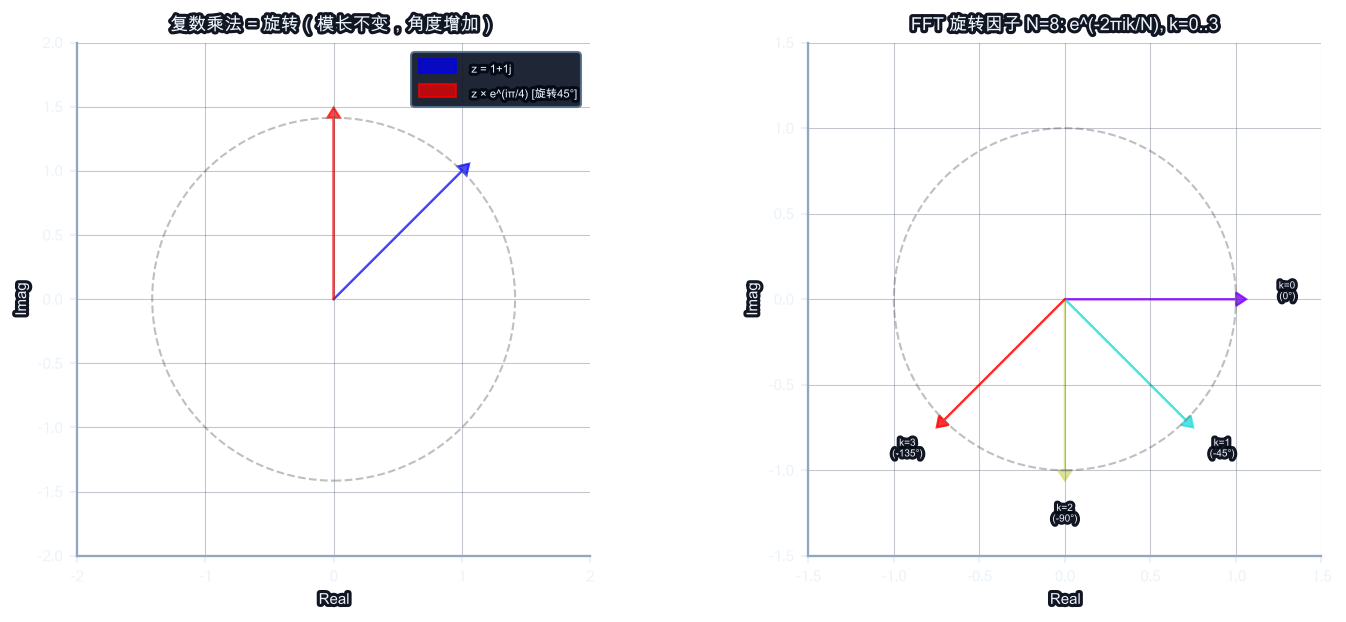

In [2]:
# 演示：复数乘法就是旋转
import numpy as np
import matplotlib.pyplot as plt

# 例 1：(1+1j) 乘以 e^(iπ/4) = 旋转 45°
z1 = 1 + 1j
angle1 = np.pi / 4
rot1 = np.exp(1j * angle1)
z1_rotated = rot1 * z1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))

# 左图：旋转 45°
ax1.arrow(0, 0, z1.real, z1.imag, head_width=0.1, head_length=0.08, fc='blue', ec='blue', alpha=0.7, label='z = 1+1j')
ax1.arrow(0, 0, z1_rotated.real, z1_rotated.imag, head_width=0.1, head_length=0.08, fc='red', ec='red', alpha=0.7, label=f'z × e^(iπ/4) [旋转45°]')
circle = plt.Circle((0, 0), np.abs(z1), fill=False, linestyle='--', color='gray', alpha=0.5)
ax1.add_patch(circle)
ax1.set_xlim(-2, 2); ax1.set_ylim(-2, 2)
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('Real'); ax1.set_ylabel('Imag')
ax1.set_title('复数乘法 = 旋转（模长不变，角度增加）')
ax1.legend()

# 右图：旋转因子逐步旋转
N = 8
k_vals = np.arange(N // 2)
twiddle_vals = np.exp(-2j * np.pi * k_vals / N)
colors = plt.cm.rainbow(np.linspace(0, 1, len(twiddle_vals)))
for k, tw, col in zip(k_vals, twiddle_vals, colors):
    angle_deg = -360 * k / N
    ax2.arrow(0, 0, tw.real, tw.imag, head_width=0.08, head_length=0.06, fc=col, ec=col, alpha=0.8)
    ax2.text(tw.real*1.3, tw.imag*1.3, f'k={k}\n({angle_deg:.0f}°)', fontsize=8, ha='center')
circle = plt.Circle((0, 0), 1, fill=False, linestyle='--', color='gray', alpha=0.5)
ax2.add_patch(circle)
ax2.set_xlim(-1.5, 1.5); ax2.set_ylim(-1.5, 1.5)
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('Real'); ax2.set_ylabel('Imag')
ax2.set_title(f'FFT 旋转因子 N={N}: e^(-2πik/N), k=0..{N//2-1}')

plt.tight_layout()
plt.show()

# 数值演示
print("手工计算复数乘法：(1+0j) × e^(-iπ/2)")
a = 1 + 0j
b = np.exp(-1j * np.pi / 2)
result = a * b
print(f"  e^(-iπ/2) = {b:.4f}  (应该是 -i = 0-1j)")
print(f"  (1+0j) × {b:.4f} = {result:.4f}  (旋转 -90°，从东转向南)")
print()

print("手工计算：x_odd 乘旋转因子后 N=4, k=1 的情形")
O_k1 = 2 + 0j  # 假设 O[1] = 2+0j
twiddle_4_1 = np.exp(-2j * np.pi * 1 / 4)
result = O_k1 * twiddle_4_1
print(f"  O[1] = {O_k1}")
print(f"  W_4^1 = e^(-2πi/4) = e^(-πi/2) = {twiddle_4_1:.4f}")
print(f"  O[1] × W_4^1 = {O_k1} × {twiddle_4_1:.4f} = {result:.4f}  (旋转 -90°)")


## 具体手工示例：N=2 和 N=4 的 FFT 计算

现在让我们用实际的数字来走一遍 Cooley-Tukey 公式，这样你就能看到"拆分→合并"的具体数值过程。

### 例子 1：N=2，输入 $x = [1, 2]$

对于长度 2 的输入，按照 Cooley-Tukey：

**偶奇拆分**：
- $x_{\text{even}} = x[0] = [1]$  （只有一个元素，长度 = 1）
- $x_{\text{odd}} = x[1] = [2]$  （只有一个元素，长度 = 1）

**递归基**（$N=1$ 时直接返回）：
- $E = \text{FFT}([1]) = [1]$  （长度为 1 的信号，DFT 就是它本身）
- $O = \text{FFT}([2]) = [2]$

**旋转因子**（k 的范围是 0..N/2-1 = 0..0，所以只有一个值）：
- $k=0$：$W_2^0 = e^{-2\pi i \cdot 0 / 2} = e^0 = 1$

**蝶形合并**：
- $X[0] = E[0] + W_2^0 \cdot O[0] = 1 + 1 \cdot 2 = 3$
- $X[1] = E[0] - W_2^0 \cdot O[0] = 1 - 1 \cdot 2 = -1$

**答案**：$X = [3, -1]$

**验证**（用 DFT 定义）：
- $X[0] = x[0] \cdot e^0 + x[1] \cdot e^0 = 1 + 2 = 3$ ✓
- $X[1] = x[0] \cdot e^0 + x[1] \cdot e^{-2\pi i} = 1 + 2 \cdot (-1) = -1$ ✓

### 例子 2：N=4，输入 $x = [1, 0, -1, 0]$（学生白板题）

**第 1 层：拆分**
- $x_{\text{even}} = x[0,2] = [1, -1]$
- $x_{\text{odd}} = x[1,3] = [0, 0]$

**第 2 层：递归到 N=2**

对 $x_{\text{even}} = [1, -1]` 用上面的例子方法（但数值不同）：
- E 的偶数部分 = $[1]$，E 的奇数部分 = $[-1]$
- 旋转因子：$W_2^0 = 1$
- $E = [\underbrace{1 + (-1) \cdot 1}_{0}, \underbrace{1 - (-1) \cdot 1}_{2}] = [0, 2]$

对 $x_{\text{odd}} = [0, 0]$：
- O 的偶数部分 = $[0]$，O 的奇数部分 = $[0]$
- 旋转因子：$W_2^0 = 1$
- $O = [0 + 0 \cdot 1, 0 - 0 \cdot 1] = [0, 0]$

**第 1 层：合并 E 和 O**

现在我们有 $E = [0, 2]$ 和 $O = [0, 0]$，要用旋转因子合并成长度 4 的 $X$。

- $k$ 的范围是 0..1（$N/2 - 1$）
- $k=0$：$W_4^0 = e^{-2\pi i \cdot 0 / 4} = 1$
  - $X[0] = E[0] + 1 \cdot O[0] = 0 + 0 = 0$
  - $X[2] = E[0] - 1 \cdot O[0] = 0 - 0 = 0$
- $k=1$：$W_4^1 = e^{-2\pi i / 4} = e^{-i\pi/2} = -i$
  - $X[1] = E[1] + (-i) \cdot O[1] = 2 + (-i) \cdot 0 = 2$
  - $X[3] = E[1] - (-i) \cdot O[1] = 2 - (-i) \cdot 0 = 2$

**答案**：$X = [0, 2, 0, 2]$

**验证**（用 DFT 定义）：
- $X[0] = 1 + 0 - 1 + 0 = 0$ ✓
- $X[1] = 1 \cdot e^0 + 0 \cdot e^{-i\pi/2} + (-1) \cdot e^{-i\pi} + 0 \cdot e^{-3i\pi/2}$
  $= 1 + 0 + (-1) \cdot (-1) + 0 = 1 + 1 = 2$ ✓

现在你看到了"从小问题（N=2）递归解决、再层层合并"的具体过程。

In [3]:
# 验证上面两个手工例子
import numpy as np

print("=" * 60)
print("例子 1 验证：N=2, x=[1, 2]")
print("=" * 60)
x1 = np.array([1, 2], dtype=complex)
X1_manual = np.array([3, -1], dtype=complex)
X1_numpy = np.fft.fft(x1)
print(f"手工计算：X = {X1_manual}")
print(f"numpy.fft：X = {X1_numpy}")
print(f"是否相同：{np.allclose(X1_manual, X1_numpy)}")
print()

print("=" * 60)
print("例子 2 验证：N=4, x=[1, 0, -1, 0]")
print("=" * 60)
x2 = np.array([1, 0, -1, 0], dtype=complex)
X2_manual = np.array([0, 2, 0, 2], dtype=complex)
X2_numpy = np.fft.fft(x2)
print(f"手工计算：X = {X2_manual}")
print(f"numpy.fft：X = {np.round(X2_numpy, 4)}")
print(f"是否相同：{np.allclose(X2_manual, X2_numpy)}")
print()

# 详细拆解例子 2 的中间步骤
print("=" * 60)
print("例子 2 详解：逐步递归过程")
print("=" * 60)
x2 = np.array([1, 0, -1, 0], dtype=complex)
x_even = x2[::2]  # [1, -1]
x_odd = x2[1::2]  # [0, 0]
print(f"原始 x = {x2}")
print(f"  偶数位 x_even = x[::2] = {x_even}")
print(f"  奇数位 x_odd = x[1::2] = {x_odd}")
print()

E = np.fft.fft(x_even)
O = np.fft.fft(x_odd)
print(f"递归 FFT(偶数位)：E = FFT({x_even}) = {np.round(E, 4)}")
print(f"递归 FFT(奇数位)：O = FFT({x_odd}) = {np.round(O, 4)}")
print()

N = len(x2)
k = np.arange(N // 2)
twiddle = np.exp(-2j * np.pi * k / N)
print(f"旋转因子 k={k}:")
for ki, tw in zip(k, twiddle):
    print(f"  W_4^{ki} = e^(-2πi·{ki}/4) = {tw:.4f}")
print()

top = E + twiddle * O
bottom = E - twiddle * O
X_reconstructed = np.concatenate([top, bottom])
print(f"蝶形合并：")
print(f"  X[0..1] = E + twiddle*O = {np.round(E, 4)} + {np.round(twiddle*O, 4)} = {np.round(top, 4)}")
print(f"  X[2..3] = E - twiddle*O = {np.round(E, 4)} - {np.round(twiddle*O, 4)} = {np.round(bottom, 4)}")
print(f"拼接结果：X = {np.round(X_reconstructed, 4)}")
print(f"numpy.fft 结果：{np.round(np.fft.fft(x2), 4)}")
print(f"是否相同：{np.allclose(X_reconstructed, np.fft.fft(x2))}")


例子 1 验证：N=2, x=[1, 2]
手工计算：X = [ 3.+0.j -1.+0.j]
numpy.fft：X = [ 3.+0.j -1.+0.j]
是否相同：True

例子 2 验证：N=4, x=[1, 0, -1, 0]
手工计算：X = [0.+0.j 2.+0.j 0.+0.j 2.+0.j]
numpy.fft：X = [0.+0.j 2.+0.j 0.+0.j 2.+0.j]
是否相同：True

例子 2 详解：逐步递归过程
原始 x = [ 1.+0.j  0.+0.j -1.+0.j  0.+0.j]
  偶数位 x_even = x[::2] = [ 1.+0.j -1.+0.j]
  奇数位 x_odd = x[1::2] = [0.+0.j 0.+0.j]

递归 FFT(偶数位)：E = FFT([ 1.+0.j -1.+0.j]) = [0.+0.j 2.+0.j]
递归 FFT(奇数位)：O = FFT([0.+0.j 0.+0.j]) = [0.+0.j 0.+0.j]

旋转因子 k=[0 1]:
  W_4^0 = e^(-2πi·0/4) = 1.0000+0.0000j
  W_4^1 = e^(-2πi·1/4) = 0.0000-1.0000j

蝶形合并：
  X[0..1] = E + twiddle*O = [0.+0.j 2.+0.j] + [0.+0.j 0.+0.j] = [0.+0.j 2.+0.j]
  X[2..3] = E - twiddle*O = [0.+0.j 2.+0.j] - [0.+0.j 0.+0.j] = [0.+0.j 2.+0.j]
拼接结果：X = [0.+0.j 2.+0.j 0.+0.j 2.+0.j]
numpy.fft 结果：[0.+0.j 2.+0.j 0.+0.j 2.+0.j]
是否相同：True


## 快速复习：代码里会用到的 NumPy 基础

如果你只学过 Python 的 `print`、变量、`for` 循环和列表，下面是 `my_fft` 里出现的三个关键 NumPy 操作。

### 1. `np.arange(N // 2)`——生成整数数组

```python
k = np.arange(4)  # 生成数组 [0, 1, 2, 3]
k = np.arange(3)  # 生成数组 [0, 1, 2]
k = np.arange(4 // 2)  # 生成数组 [0, 1]（整数除法 4//2=2）
```

这用来"批量生成" k 值，而不是一个一个 `for` 循环。

### 2. 数组切片 `x[::2]` 和 `x[1::2]`——提取偶数/奇数下标

```python
x = np.array([1, 2, 3, 4, 5, 6])
x[::2]   # 每隔一个取一个，起点=0：[1, 3, 5]
x[1::2]  # 每隔一个取一个，起点=1：[2, 4, 6]
```

在 FFT 里，`x[::2]` 是偶数位，`x[1::2]` 是奇数位。

### 3. 向量化乘法 `twiddle * O`——逐元素相乘

```python
twiddle = np.array([1+0j, -0.7+0.7j])  # 两个复数
O = np.array([2+0j, 3+0j])  # 两个复数
result = twiddle * O  # 逐元素相乘：[(1+0j)*(2+0j), (-0.7+0.7j)*(3+0j)]
                      # 结果：[2+0j, -2.1+2.1j]
```

这是"向量化"操作——一行代码对数组的每个元素都做乘法，不需要写 `for` 循环。

In [4]:
# NumPy 基础操作演示
import numpy as np

print("操作 1：np.arange(N // 2)")
print("-" * 50)
for N in [4, 8, 16]:
    k = np.arange(N // 2)
    print(f"  N={N}:  np.arange({N}//2) = np.arange({N//2}) = {k}")
print()

print("操作 2：数组切片 x[::2] 和 x[1::2]")
print("-" * 50)
x = np.array([10, 20, 30, 40, 50, 60, 70, 80])
print(f"  x = {x}")
print(f"  x[::2]   (偶数下标) = {x[::2]}")
print(f"  x[1::2]  (奇数下标) = {x[1::2]}")
print()

print("操作 3：向量化复数乘法")
print("-" * 50)
# 模拟 N=4 的情形
N = 4
k = np.arange(N // 2)
twiddle = np.exp(-2j * np.pi * k / N)
O = np.array([2+0j, 1+1j])  # 假设这是某次递归的结果

print(f"  N={N}")
print(f"  k = {k}")
print(f"  twiddle = np.exp(-2j*π*k/N) = {np.round(twiddle, 4)}")
print(f"  O = {O}")
print(f"  twiddle * O = {np.round(twiddle * O, 4)}")
print()
print("  ✓ 对应蝶形公式中的 'twiddle * O' 部分")


操作 1：np.arange(N // 2)
--------------------------------------------------
  N=4:  np.arange(4//2) = np.arange(2) = [0 1]
  N=8:  np.arange(8//2) = np.arange(4) = [0 1 2 3]
  N=16:  np.arange(16//2) = np.arange(8) = [0 1 2 3 4 5 6 7]

操作 2：数组切片 x[::2] 和 x[1::2]
--------------------------------------------------
  x = [10 20 30 40 50 60 70 80]
  x[::2]   (偶数下标) = [10 30 50 70]
  x[1::2]  (奇数下标) = [20 40 60 80]

操作 3：向量化复数乘法
--------------------------------------------------
  N=4
  k = [0 1]
  twiddle = np.exp(-2j*π*k/N) = [1.+0.j 0.-1.j]
  O = [2.+0.j 1.+1.j]
  twiddle * O = [2.+0.j 1.-1.j]

  ✓ 对应蝶形公式中的 'twiddle * O' 部分


## 深度可视化：递归执行的逐步过程（用实际数值）

"递归"这个词听起来很抽象。让我们用一个 N=4 的真实例子，逐步展示程序**实际执行的顺序**和**每一步的数值**。

### 执行轨迹：`my_fft([1, 0, -1, 0])` 的完整过程

```
调用栈                              返回值
─────────────────────────────────────────────────────────
1️⃣  my_fft([1,0,-1,0], N=4)        进入，还没返回
    ├─ E = my_fft([1,-1], N=2)      递归调用偶数部分，进入
    │  ├─ E = my_fft([1], N=1)      进入，触底
    │  │  return [1]              ◀─ 返回：递归基
    │  ├─ O = my_fft([-1], N=1)     进入，触底
    │  │  return [-1]             ◀─ 返回：递归基
    │  ├─ 蝶形合并 E=[1], O=[-1]
    │  │   k=0: W_2^0 = 1
    │  │   top    = E + twiddle*O = [1] + 1*[-1] = [0]
    │  │   bottom = E - twiddle*O = [1] - 1*[-1] = [2]
    │  return [0, 2]              ◀─ 返回：E 完毕
    ├─ O = my_fft([0,0], N=2)       递归调用奇数部分，进入
    │  ├─ my_fft([0], N=1) → [0]
    │  ├─ my_fft([0], N=1) → [0]
    │  ├─ 蝶形合并
    │  return [0, 0]              ◀─ 返回：O 完毕
    ├─ E=[0,2], O=[0,0]，现在合并它们
    │  k=[0,1]:
    │    W_4^0 = e^0 = 1
    │    W_4^1 = e^(-iπ/2) = -i
    │  top    = [0,2] + [1,-i]*[0,0] = [0,2] + [0,0] = [0,2]
    │  bottom = [0,2] - [1,-i]*[0,0] = [0,2] - [0,0] = [0,2]
    return [0,2,0,2]             ◀─ 返回：FFT 完成
```

关键观察：
- **深度优先**：`my_fft([1,-1], N=2)` 完全返回后，才开始计算 `my_fft([0,0], N=2)`
- **递归基是关键**：当 N=1 时，直接返回输入（第 1 行的 `return [1]`），整个递归才能停止
- **两次蝶形**：N=2 级别做一次蝶形合并（得到 E 和 O），N=4 级别再做一次（把 E、O 合并成最终结果）

In [5]:
import numpy as np
import time
from aurora.audio.transforms import fft as aurora_fft

## 定位图：N=8 递归分治树

先看树的结构再动手写递归。向下是**拆分**（偶/奇），向上是**蝶形合并**；3 层对应 `log₂8=3` 次递归，每层 N/2=4 次蝶形乘法，总计 12 次——朴素 DFT 要 64 次。

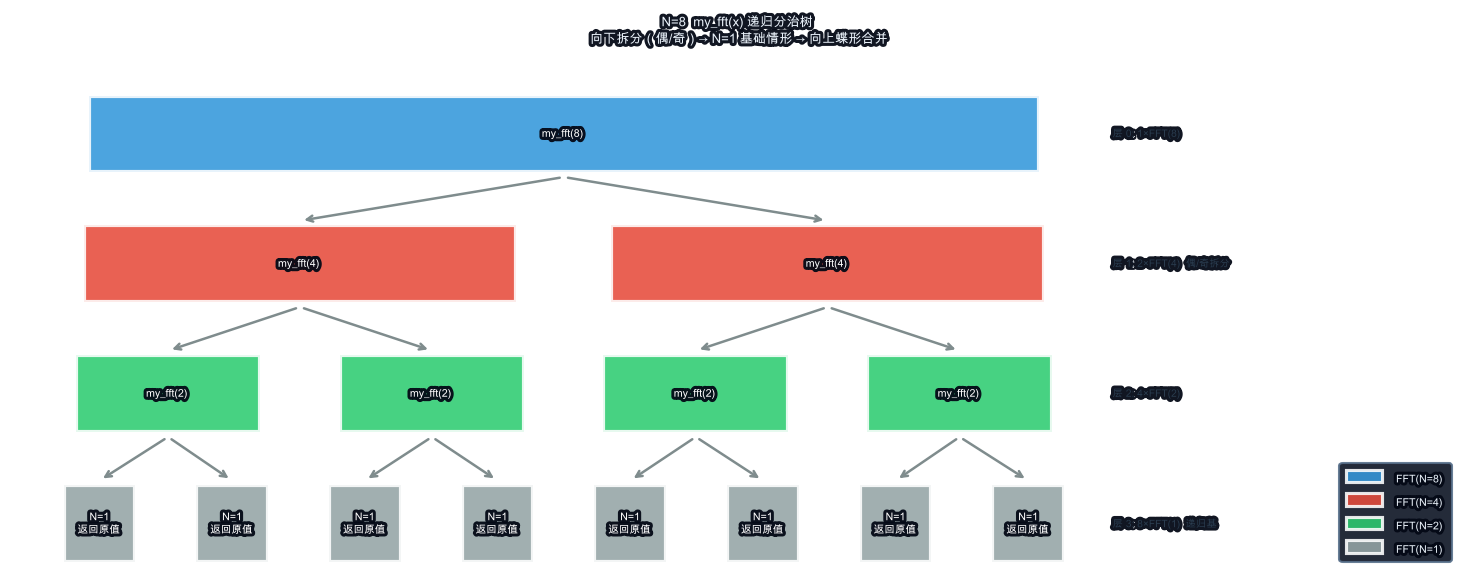

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(10, 4.2))

COLORS = {8: '#3498db', 4: '#e74c3c', 2: '#2ecc71', 1: '#95a5a6'}
LABELS = {8: 'my_fft(8)', 4: 'my_fft(4)', 2: 'my_fft(2)', 1: 'N=1\n返回原值'}
ys = [3.5, 2.4, 1.3, 0.2]   # y-centers per level
bh = 0.65                     # block height

def box(ax, cx, cy, w, n):
    ax.add_patch(plt.Rectangle((cx - w/2, cy - bh/2), w, bh,
                                fc=COLORS[n], ec='white', lw=2, alpha=0.88, zorder=3))
    ax.text(cx, cy, LABELS[n], ha='center', va='center',
            fontsize=8.5, fontweight='bold', color='white', zorder=4)

# Boxes at each level
box(ax, 5.0, ys[0], 9.0, 8)
for cx in [2.5, 7.5]:
    box(ax, cx, ys[1], 4.1, 4)
for cx in [1.25, 3.75, 6.25, 8.75]:
    box(ax, cx, ys[2], 1.75, 2)
for cx in np.linspace(0.6, 9.4, 8):
    box(ax, cx, ys[3], 0.68, 1)

# Arrows (split direction, going down)
kw = dict(arrowstyle='->', color='#7f8c8d', lw=1.2)
for cx in [2.5, 7.5]:
    ax.annotate('', xy=(cx, ys[1] + bh/2 + 0.04),
                xytext=(5.0, ys[0] - bh/2 - 0.04), arrowprops=kw, zorder=2)
for parent, children in [(2.5, [1.25, 3.75]), (7.5, [6.25, 8.75])]:
    for cx in children:
        ax.annotate('', xy=(cx, ys[2] + bh/2 + 0.04),
                    xytext=(parent, ys[1] - bh/2 - 0.04), arrowprops=kw, zorder=2)
child_xs = np.linspace(0.6, 9.4, 8)
for i, parent in enumerate([1.25, 3.75, 6.25, 8.75]):
    for cx in child_xs[i * 2:(i + 1) * 2]:
        ax.annotate('', xy=(cx, ys[3] + bh/2 + 0.04),
                    xytext=(parent, ys[2] - bh/2 - 0.04), arrowprops=kw, zorder=2)

# Right-side annotations
for y, lbl in zip(ys, ['层 0: 1×FFT(8)', '层 1: 2×FFT(4)  偶/奇拆分',
                        '层 2: 4×FFT(2)', '层 3: 8×FFT(1)  递归基']):
    ax.text(10.2, y, lbl, ha='left', va='center', fontsize=8.2, color='#2c3e50')

ax.set_xlim(-0.2, 13.5)
ax.set_ylim(-0.2, 4.2)
ax.axis('off')
ax.set_title('N=8  my_fft(x) 递归分治树\n'
             '向下拆分（偶/奇）→ N=1 基础情形 → 向上蝶形合并',
             fontsize=10.5, fontweight='bold', pad=4)
ax.legend(handles=[mpatches.Patch(fc=COLORS[n], ec='white', lw=1.5, alpha=0.88,
                                   label=f'FFT(N={n})') for n in [8, 4, 2, 1]],
          loc='lower right', fontsize=8.5, framealpha=0.9)
plt.tight_layout()
plt.show()

## 1. 递归结构：蝶形合并

Cooley-Tukey 核心恒等式：

```
X[k]     = E[k] + exp(-2πi·k/N) · O[k]      (k = 0..N/2-1)
X[k+N/2] = E[k] - exp(-2πi·k/N) · O[k]      (k = 0..N/2-1)
```

其中 `E = fft(x[::2])`（偶数下标），`O = fft(x[1::2])`（奇数下标）。

### 为什么第二个式子用减号？

这不是任意选择，而是**从 DFT 定义的周期性自动推导出来的**（见前面的推导小节）。

简单说：
- 前半部分 $X[k]$ 用的是 $E[k] + W^k \cdot O[k]$
- 后半部分 $X[k+N/2]$ 用的是 $E[k] - W^k \cdot O[k]$

减号出现是因为 $e^{-2\pi i (k+N/2) n / N}$ 中，指数里的 $(k+N/2)$ 加上去后，对**奇数 $n=2m+1$ 项**会多出一个 $e^{-\pi i} = -1$ 的因子。这就是为什么"不需要额外乘法"——减号是"免费"的，DFT 公式自己给出的。

旋转因子 `exp(-2πi·k/N)` 乘完就是「蝶形（butterfly）」操作。
递归基：`N==1` 时 DFT 就是原值本身，直接返回。

In [7]:
# 演示：手算 N=2 的 DFT vs FFT 公式
x2 = np.array([3.0, 7.0])
# DFT 定义: X[k] = sum_n x[n]*exp(-2pi*i*k*n/N)
X2_def = np.array([
    x2[0] + x2[1],           # k=0: exp(0)=1
    x2[0] - x2[1],           # k=1: exp(-pi*i)=-1
], dtype=complex)
X2_np = np.fft.fft(x2)
print('手算 X[0]:', X2_def[0], '  numpy:', X2_np[0])
print('手算 X[1]:', X2_def[1], '  numpy:', X2_np[1])
print('误差:', np.max(np.abs(X2_def - X2_np)))

手算 X[0]: (10+0j)   numpy: (10+0j)
手算 X[1]: (-4+0j)   numpy: (-4+0j)
误差: 0.0


## 2. 必须是 2 的幂；非 2 的幂用补零（zero padding）

Cooley-Tukey 每步把 N 对半分，要求 N 是 2 的幂次（`N = 2^k`）。这是**算法设计的要求**，不是"编程的限制"。

为什么？因为递归每层都必须**恰好对半**：N → N/2 → N/4 → ... → 1。如果 N 不是 2 的幂（比如 N=5），你无法一直对半分下去（5 → 2.5 ✗）。

### 非 2 幂的信号怎么办？

标准做法是找最小的 `N_padded = 2^ceil(log2(L))`，在末尾补零到 N_padded，得到 N_padded 点频谱。
```
L = 5  →  N_padded = 2^ceil(log2(5)) = 2^3 = 8
L = 100  →  N_padded = 2^ceil(log2(100)) = 2^7 = 128
```

注意：补零**不会增加**物理频率分辨率（那由原始信号的**时长**决定），只是把频率网格插得更密，让谱线看起来更平滑。

### 例子：用真实信号说明

假设你有一个 5 秒的音频，采样率 16kHz，共 80000 个样本。把它补零到 2^17 = 131072 后，频率分辨率仍然是 `16000 Hz / 80000 = 0.2 Hz`（来自原始 5 秒时长），不是 `16000 Hz / 131072`。补零只是让频率网格分布更密集，不改变"物理分辨率"。

示例 1：任意长度补零到 2 的幂
------------------------------------------------------------
  原始长度    5 → 补零到     8
  原始长度  100 → 补零到   128
  原始长度 1000 → 补零到  1024

示例 2：补零不改变'物理频率分辨率'
------------------------------------------------------------
信号时长：0.5 秒，采样率 8000 Hz
原始样本数：4000
补零到 2^12 = 4096
物理频率分辨率：8000 Hz / 4000 = 2.00 Hz
  (这由原始 0.5 秒时长决定，不变)
补零后频率网格点数：4096
  (更密集的网格，但两个 440/880 Hz 信号的分辨能力不变)

总结：补零只改变频率网格的**密度**（从 8000/4000=2Hz 网格
     变成 8000/4096≈1.95Hz 更密的网格），不改变**物理分辨率**。


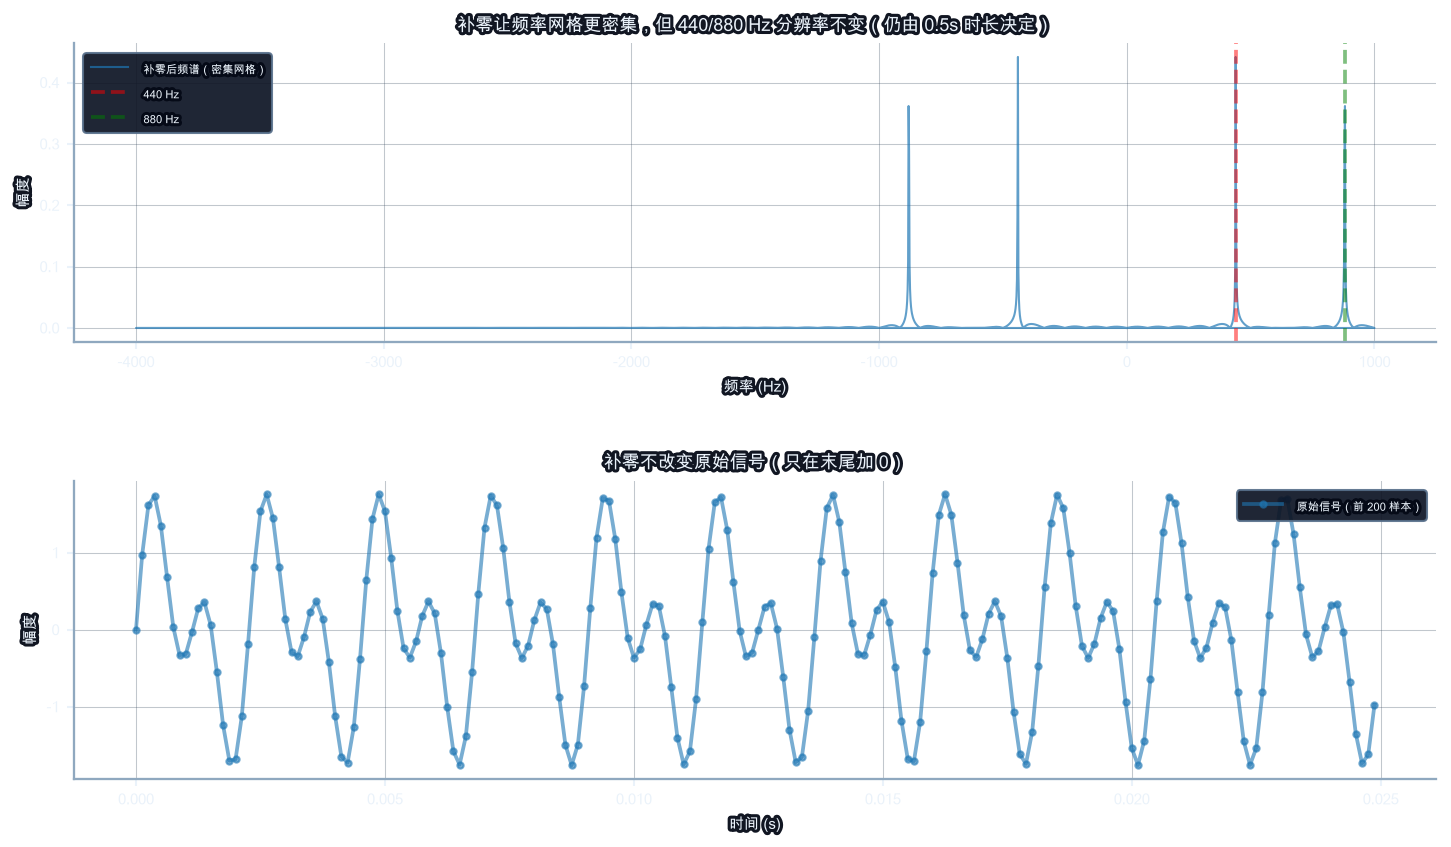

In [8]:
# 演示：N=5 补零到 8，以及补零对频率分辨率的影响
import numpy as np
import matplotlib.pyplot as plt

# 构造一个简单信号：440 Hz + 880 Hz 的混合（两个音符）
sr = 8000  # 采样率 8kHz
duration = 1.0  # 1 秒
t = np.linspace(0, duration, int(sr * duration), endpoint=False)
f1, f2 = 440, 880
x_long = np.sin(2 * np.pi * f1 * t) + np.sin(2 * np.pi * f2 * t)

print("示例 1：任意长度补零到 2 的幂")
print("-" * 60)
for L in [5, 100, 1000]:
    x = x_long[:L]
    N_padded = 2 ** int(np.ceil(np.log2(L)))
    x_pad = np.pad(x, (0, N_padded - L))
    print(f"  原始长度 {L:4d} → 补零到 {N_padded:5d}")

print()
print("示例 2：补零不改变'物理频率分辨率'")
print("-" * 60)
# 用真实 1 秒信号，取前 500 个样本（0.5 秒）
x_0p5s = x_long[:4000]  # 0.5 秒，8000 Hz × 0.5 = 4000 样本
print(f"信号时长：0.5 秒，采样率 8000 Hz")
print(f"原始样本数：{len(x_0p5s)}")

# 不补零，直接 FFT（假设 4000 是 2 的幂... 实际不是，但为了演示原理）
N_pad_to = 2 ** int(np.ceil(np.log2(len(x_0p5s))))
print(f"补零到 2^{int(np.log2(N_pad_to))} = {N_pad_to}")

x_padded = np.pad(x_0p5s, (0, N_pad_to - len(x_0p5s)))
X_padded = np.fft.fft(x_padded)
freq_resolution = sr / len(x_0p5s)  # 物理分辨率：由原始时长决定
freq_axis = np.fft.fftfreq(N_pad_to, 1/sr)

print(f"物理频率分辨率：{sr} Hz / {len(x_0p5s)} = {freq_resolution:.2f} Hz")
print(f"  (这由原始 0.5 秒时长决定，不变)")
print(f"补零后频率网格点数：{N_pad_to}")
print(f"  (更密集的网格，但两个 440/880 Hz 信号的分辨能力不变)")
print()

# 绘制对比
fig, axes = plt.subplots(2, 1, figsize=(10, 6))
# 幅度谱（前 1000 Hz 范围内）
ax = axes[0]
freq_mask = freq_axis <= 1000
ax.plot(freq_axis[freq_mask], np.abs(X_padded[freq_mask]) / len(x_0p5s), 
        linewidth=1, alpha=0.7, label='补零后频谱（密集网格）')
ax.axvline(440, color='red', linestyle='--', alpha=0.5, label='440 Hz')
ax.axvline(880, color='green', linestyle='--', alpha=0.5, label='880 Hz')
ax.set_xlabel('频率 (Hz)')
ax.set_ylabel('幅度')
ax.set_title('补零让频率网格更密集，但 440/880 Hz 分辨率不变（仍由 0.5s 时长决定）')
ax.legend()
ax.grid(True, alpha=0.3)

# 示意补零前后
ax = axes[1]
x_vis = x_0p5s[:200]  # 取前 200 个样本可视化
x_pad_vis = x_padded[:200]
t_vis = np.arange(len(x_vis)) / sr
ax.plot(t_vis, x_vis, 'o-', markersize=3, alpha=0.6, label='原始信号（前 200 样本）')
ax.set_xlabel('时间 (s)')
ax.set_ylabel('幅度')
ax.set_title('补零不改变原始信号（只在末尾加 0）')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("总结：补零只改变频率网格的**密度**（从 8000/4000=2Hz 网格")
print("     变成 8000/4096≈1.95Hz 更密的网格），不改变**物理分辨率**。")


## 3. 数值误差：浮点累积 < 1e-10

递归 FFT 有 `log₂N` 层，每层做浮点乘法；误差随层数线性累积，量级约 `N·log₂N·ε_machine`。
对 `N=1024`，double 精度下误差约 `1024·10·2.2e-16 ≈ 2e-12`，远低于 `1e-10`。
验证工具：`np.testing.assert_allclose(my_result, reference, atol=1e-10)`，失败时会打印最大偏差位置。

```
# atol 是绝对容忍，rtol 是相对容忍；对复数频谱两者都要设
np.testing.assert_allclose(A, B, rtol=1e-9, atol=1e-10)
```

In [9]:
# 演示：量化不同 N 下的浮点误差（朴素 DFT vs numpy.fft，说明误差量级）
print("     N  max_abs_err (naive_dft vs numpy.fft)")
for N in [4, 16, 64, 256, 1024, 4096]:
    x = np.random.randn(N)
    ref = np.fft.fft(x)
    n_arr = np.arange(N)
    k_arr = n_arr.reshape((N, 1))
    M_naive = np.exp(-2j * np.pi * k_arr * n_arr / N)
    naive = M_naive @ x.astype(complex)
    err = np.max(np.abs(naive - ref))  # naive O(N²) 与 numpy 的差异
    print(f"{N:>6}  {err:.2e}")
print("\n(以上为朴素 DFT 与 numpy.fft 误差；实现 my_fft 后 cell 13 将真正验证其误差 < 1e-9)")


     N  max_abs_err (naive_dft vs numpy.fft)
     4  1.30e-15
    16  2.86e-14
    64  2.78e-13
   256  3.08e-12
  1024  3.54e-11
  4096  2.37e-10

(以上为朴素 DFT 与 numpy.fft 误差；实现 my_fft 后 cell 13 将真正验证其误差 < 1e-9)


## 调用栈可视化：`my_fft` 到底按什么顺序执行？(理解程序递归，不是 FFT 数学)

上面的分治树画的是"结构"；动手写 `return` 之前，还得看清程序**真正的执行顺序**。递归是**深度优先**的：`my_fft(x[::2])` 会一路钻到最底，返回后才轮到 `my_fft(x[1::2])`。以 N=4 为例，把每次进入 / 退出函数按时间先后排开：

```text
my_fft([a,b,c,d])              进入，N=4
├─ E = my_fft([a,c])           先算偶数半，进入 N=2
│   ├─ my_fft([a]) → [a]       触底：N==1 直接返回（递归基）
│   ├─ my_fft([c]) → [c]       触底：N==1 直接返回
│   └─ 蝶形合并 → E             两个单点都回来了，才合并成 E
├─ O = my_fft([b,d])           偶数半彻底返回后，才开始算奇数半
│   ├─ my_fft([b]) → [b]
│   ├─ my_fft([d]) → [d]
│   └─ 蝶形合并 → O
└─ 蝶形合并(E, O) → X           E、O 都就位，最后一次合并得到答案
```

读法：**每一层竖线，都是一个"还没返回、正挂在调用栈上"的 `my_fft`**。栈最深处永远是长度为 1 的调用——它不再往下递归、直接返回，成为整棵树开始"收线"的起点。所以你写代码时，`if N == 1: return ...` 这一行的位置，决定了这张图能不能正确收尾；漏了它，递归就会无限下钻（`RecursionError`）。

## 4. ✏️ 实现 `my_fft(x)`（递归 Cooley-Tukey）

**五步提示**：

1. 递归基：长度为 1 时直接返回复数输入
2. 偶奇拆分：把偶数位和奇数位分成两个子问题
3. 旋转因子：`twiddle` 只负责一圈里的相位步进
4. 蝶形合并：把 `E` 和 `O` 组合成上半 / 下半频谱
5. 拼接返回：先上半，再下半

**精度要求**：`np.allclose(my_fft(x), np.fft.fft(x), atol=1e-9)` 通过

**卡住回**：L38 的蝶形图、L38/L39 的分治树，或 `solutions/L39_fft_implement_solutions.md`


In [10]:
def my_fft(x: np.ndarray) -> np.ndarray:
    """递归 Cooley-Tukey radix-2 FFT。x 长度必须是 2 的幂。"""
    N = len(x)
    # ✏️ TODO 1: 递归基 — N==1 时直接返回
    raise NotImplementedError("TODO 1-5: 完整实现 Cooley-Tukey 递归 FFT（递归基/偶奇拆分/旋转因子/蝶形合并/拼接）")

    # ✏️ TODO 2: 递归拆分偶/奇下标
    E = ...  # my_fft(x[::2])
    O = ...  # my_fft(x[1::2])

    # ✏️ TODO 3: 旋转因子 twiddle = exp(-2pi*i * k / N), k = 0..N/2-1
    k = np.arange(N // 2)
    twiddle = ...

    # ✏️ TODO 4: 蝶形合并
    top    = ...  # E + twiddle * O
    bottom = ...  # E - twiddle * O

    # ✏️ TODO 5: 拼接返回
    return ...

In [11]:
# ── 正确性检查 ──────────────────────────────────────────────
import numpy as np
x_demo = np.array([1, 2, 3, 4, 3, 2, 1, 0], dtype=float)
try:
    out_demo = my_fft(x_demo)
    if out_demo is None or out_demo is ...:
        print("⬜ 请先实现 my_fft 的各 TODO 项")
    else:
        ref_demo = np.fft.fft(x_demo)
        print('最大误差:', np.max(np.abs(out_demo - ref_demo)))
        all_pass = True
        for N in [4, 8, 16, 64, 256]:
            x = np.random.randn(N)
            if not np.allclose(my_fft(x), np.fft.fft(x), atol=1e-10):
                print(f'✗ N={N} 失败'); all_pass = False
        if all_pass:
            print('✅ 所有 N in [4,8,16,64,256] 通过，误差 < 1e-9')
except (NotImplementedError, TypeError):
    print("⬜ 请先实现 my_fft 的各 TODO 项，再运行检查格")
except TypeError:
    print("⬜ 请先替换 ... 占位符后再运行检查格")
except RecursionError:
    print("⬜ my_fft 递归异常：检查递归基（N==1 时的 return）")


⬜ 请先实现 my_fft 的各 TODO 项，再运行检查格


In [12]:
# ── Aurora 连接：验证 my_fft 与 aurora_fft 数值等价 ─────────────────────────────
# aurora_fft 已在 cell 2 导入，此处做最终比较
try:
    x_check = np.array([1, 2, 3, 4, 3, 2, 1, 0], dtype=float)
    out_my = my_fft(x_check)
    if out_my is None or out_my is ...:
        print("□ 请先实现 my_fft 后再运行此格")
    else:
        out_aurora = aurora_fft(x_check)
        max_diff = float(np.max(np.abs(out_my - out_aurora)))
        np.testing.assert_allclose(out_my, out_aurora, atol=1e-10,
            err_msg="my_fft 与 aurora_fft 输出不一致，请检查蝶形合并逻辑")
        print(f"✅ my_fft ↔ aurora_fft 最大差异: {max_diff:.2e}  (< 1e-9)")
        print("   两者数值等价，算法路径不同（递归 vs 迭代 Cooley-Tukey）")
except (NotImplementedError, TypeError):
    print("□ 请先实现 my_fft 后再运行此格")
except TypeError:
    print("□ 请先替换 ... 占位符后再运行")
except RecursionError:
    print("□ my_fft 递归异常：检查递归基（N==1 时的 return）")


□ 请先实现 my_fft 后再运行此格


## 补充 · 非 2 幂、补零与 STFT 调用约定

本课的 `my_fft(x)` 只要求处理 2 的幂长度，这是为了让递归分治保持清楚。

生产代码里也有同样的边界：

- `aurora.audio.transforms.fft(x)`：输入长度必须是 2 的幂；否则抛出 `ValueError`
- `aurora.audio.transforms.next_power_of_two(n)`：返回不小于 `n` 的最小 2 的幂
- `aurora.audio.stft.stft(...)`：在每帧送进 `rfft/fft` 前，会把 `n_fft` 防护到 2 的幂长度

所以你可以把约定记成：

```text
普通 FFT：你负责给它 2 的幂长度
STFT 流水线：每帧会按 n_fft/next_power_of_two 做补零防护
```

这会在 L44 手写 STFT 时再次出现：`win_len` / `n_fft` 通常取 256、512、1024 这类 2 的幂。


In [13]:
import numpy as np
from aurora.audio.transforms import fft, next_power_of_two

x5 = np.ones(5)
try:
    fft(x5)
except ValueError as exc:
    print("非 2 幂直接 fft 会失败：", str(exc).split(".")[0])

target = next_power_of_two(len(x5))
x_pad = np.pad(x5, (0, target - len(x5)))
X_pad = fft(x_pad)

assert target == 8
assert x_pad.shape == (8,)
assert X_pad.shape == (8,)
print(f"✅ len=5 → 补零到 {target} 后可运行；这正是 L44/STFT 会用到的边界意识")


非 2 幂直接 fft 会失败： fft() requires a power-of-two length, got 5
✅ len=5 → 补零到 8 后可运行；这正是 L44/STFT 会用到的边界意识


## 5. 参数实验：速度对比

- `N = 512`：naive DFT（O(N²)) vs `my_fft`（O(N log N)）vs `np.fft.fft`（C 扩展）
- 预期：`my_fft` 比 naive DFT 快约 `log₂(512) = 9` 倍；`np.fft.fft` 比 `my_fft` 快 10-50 倍（C 扩展 + SIMD）
- 调整 `N` 观察：倍数比例随 `N` 增大而增大（log 增益更显著）

In [ ]:
def naive_dft(x: np.ndarray) -> np.ndarray:
    """暴力 O(N²) DFT，用于速度基准对比。"""
    N = len(x)
    n = np.arange(N)
    k = n.reshape((N, 1))
    M = np.exp(-2j * np.pi * k * n / N)
    return M @ x.astype(complex)

N = 512
x_bench = np.random.randn(N)

reps = 20
t0 = time.perf_counter()
for _ in range(reps): naive_dft(x_bench)
t_naive = (time.perf_counter() - t0) / reps * 1000

t0 = time.perf_counter()
for _ in range(reps): my_fft(x_bench)
t_my = (time.perf_counter() - t0) / reps * 1000

t0 = time.perf_counter()
for _ in range(reps): np.fft.fft(x_bench)
t_np = (time.perf_counter() - t0) / reps * 1000

print(f'N={N}  (平均 {reps} 次，单位 ms)')
print(f'  naive_dft : {t_naive:8.3f} ms')
print(f'  my_fft    : {t_my:8.3f} ms   ({t_naive/t_my:.1f}× faster than naive)')
print(f'  np.fft.fft: {t_np:8.3f} ms   ({t_my/t_np:.1f}× faster than my_fft)')
print(f'\n理论加速比 naive→FFT: log₂({N}) = {np.log2(N):.1f}')

---
→ **完成 `my_fft` 实现后，打开 [L42 · FFT 图形化](L42_visual_fft.ipynb)，对照蝴蝶图与各类信号的频谱形态，检验输出是否符合直觉，再回来。**

## 🎯 未来的回报 (Future Payoff)

今天你亲手写出的这个递归 `my_fft`，会在 **L41 / L43–L44 / L60+** 一次次回来找你——L41 把它包进加窗 FFT；**L43–L44 的 STFT 会在每一帧信号上反复调用你今天写的这只 FFT**；而整条 STFT → mel → MFCC 的特征流水线（最终喂给后面的神经网络）都站在这一次递归之上。真正搞懂"一次 FFT 调用花多少钱"，你才会明白为什么实时音频要对每一帧精打细算。

## 本课收束

`my_fft(x)` 通过递归蝶形操作输出 N 个复数频谱系数，误差控制在 `1e-9` 以内，与 `aurora.audio.transforms.fft` 在数值上等价，但算法路径不一样：生产版用的是**迭代式** Cooley-Tukey（位逆序置换 + 非递归蝴蝶），L41 会实现这个迭代版本；两者都能正确驱动 STFT 的内层计算。下一课 L40 将在复数频谱上分析幅度谱与相位谱，验证频率分辨率与信号长度的关系。

---
⬇️ **通关检验**：收束小结已读；请完成下方白板挑战后再勾选自评。


## ✏️ 白板挑战：FFT 手算与递归结构（目标 10 分钟）

盖上屏幕，纸上作答：

**问 1**：`my_fft` 递归的基础情形是什么？  
（N=? 时直接返回，返回的是什么？）

**问 2**：对 N=8 的输入，递归树有几层？每层共有多少个蝶形运算？

**问 3**：`x = [1, 0, -1, 0]`，用 Cooley-Tukey 分治手算 X[1]：
- x_even = x[0,2] = [1, -1]，E = DFT([1,-1]) = ?
- x_odd  = x[1,3] = [0, 0]，O = DFT([0, 0])  = ?
- W_4^1 = e^{-πi/2} = ?
- X[1] = E[1] + W_4^1 · O[1] = ?

**问 4**：`my_fft(np.array([1,1,1,1]))` 的结果是什么？  
（提示：均匀信号的 DFT 只在 k=0 有非零值）

**问 5**：为什么 `my_fft` 要求输入长度是 2 的幂？不满足时如何解决？

推导完成后运行下面格对答案。

In [ ]:
# ✏️ 对答案格
import numpy as np

# 问1：基础情形 N=1
x1 = np.array([3.7])
X1_ref = np.fft.fft(x1)
try:
    X1 = my_fft(x1)
    assert np.allclose(X1, X1_ref, atol=1e-12)
    print(f"Q1 ✅  N=1 基础情形：my_fft([3.7])={X1}（返回输入本身作为复数）")
except (NotImplementedError, TypeError):
    print("⬜ Q1：请先实现 my_fft()，再运行对答案格")

# 问2：N=8 树结构
N8 = 8
n_layers = int(np.log2(N8))
butterflies_per_layer = N8 // 2
total_butterflies = butterflies_per_layer * n_layers
assert n_layers == 3 and butterflies_per_layer == 4 and total_butterflies == 12
print(f"Q2 ✅  N=8: {n_layers} 层，每层 {butterflies_per_layer} 个蝶形，共 {total_butterflies} 个蝶形")

# 问3：x=[1,0,-1,0] 手算 X[1]
x4 = np.array([1.0, 0.0, -1.0, 0.0])
X4_ref = np.fft.fft(x4)
# E = DFT([1,-1]) = [0, 2]
E4 = np.fft.fft(np.array([1.0, -1.0]))
O4 = np.fft.fft(np.array([0.0, 0.0]))
W41 = np.exp(-2j * np.pi * 1 / 4)
X1_calc = E4[1] + W41 * O4[1]
assert np.isclose(X1_calc, X4_ref[1], atol=1e-12)
print(f"Q3 ✅  E[1]={E4[1]:.4f}, O[1]={O4[1]:.4f}, W_4^1={W41:.4f}")
print(f"      X[1] = {E4[1]:.4f} + {W41:.4f}×{O4[1]:.4f} = {X1_calc:.4f}")
try:
    X4_mine = my_fft(x4)
    assert np.allclose(X4_mine, X4_ref, atol=1e-9)
    print(f"      my_fft 验证：{np.round(X4_mine, 4)}  ✅")
except (NotImplementedError, TypeError):
    print("      ⬜ 请先实现 my_fft()，再运行对答案格")

# 问4：x=[1,1,1,1]
x_dc = np.array([1.0, 1.0, 1.0, 1.0])
X_dc_ref = np.fft.fft(x_dc)
assert np.isclose(X_dc_ref[0], 4+0j, atol=1e-12)
assert np.allclose(X_dc_ref[1:], 0+0j, atol=1e-12)
print(f"Q4 ✅  my_fft([1,1,1,1]) = {np.round(X_dc_ref, 4)}（只有 k=0 处=4，其余=0）")

# 问5：2的幂 — 非2的幂需补零
x5 = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
N_padded = 2 ** int(np.ceil(np.log2(len(x5))))
assert N_padded == 8
x5_padded = np.pad(x5, (0, N_padded - len(x5)))
X5_padded = np.fft.fft(x5_padded)
print(f"Q5 ✅  N=5 不是2的幂，补零至 N={N_padded}；频谱长度={len(X5_padded)}（插值频率轴）")
print("\n🎉 FFT 手算挑战通过！递归 Cooley-Tukey 结构已内化。")

In [ ]:
# ✏️ 本课自评
l39_review = {
    "cooley_tukey_recursion":  None,  # 记住递归结构：base N=1，split even/odd，butterfly？True/False
    "my_fft_implemented":      None,  # my_fft 实现并通过 atol=1e-9 验证？True/False
    "error_bound_understood":  None,  # 理解浮点误差 < 1e-9 的来源（log N层累积）？True/False
    "speedup_quantified":      None,  # 知道 N=1024 时 FFT 比 DFT 快约 205 倍？True/False
    "whiteboard_passed":       None,  # 白板挑战纸上推导完成？True/False
    "stft_padding_contract":   None,  # 理解 fft 要 2 的幂、STFT 会补零防护？True/False
}

unfilled = [k for k, v in l39_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l39_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L39 全部通关！进入 L40：用频谱解释真实信号')

---

→ **下一课**　[L40 · 频谱分析实战](L40_spectrum.ipynb)

> 下节课将学习 **频谱分析实战**：幅度谱 / 相位谱 / 频率分辨率，440Hz+880Hz 混合信号。